## Semana 1

In [10]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia", output_dir="./data")
print(path)

100%|██████████| 2.29G/2.29G [00:46<00:00, 52.5MB/s]

Extracting files...


./data


### 1.1 Descripción del Problema

**Tipo de Aprendizaje: Clasificación Binaria Supervisada**

Este trabajo aborda un problema de **aprendizaje supervisado**, específicamente una tarea de **clasificación binaria**:
- **Justificación**: Contamos con datos etiquetados (imágenes de rayos X clasificadas como NORMAL o PNEUMONIA). El objetivo es aprender una función que mapee características de entrada (imágenes) a etiquetas conocidas. No es aprendizaje no supervisado porque tenemos etiquetas; tampoco es por refuerzo porque no hay retroalimentación de recompensa/castigo en un ambiente secuencial.
- **Aplicación**: Diagnóstico automático de neumonía en radiografías de tórax usando imágenes médicas como entrada.

### 1.2 Formulación Matemática del Problema

**Espacios y Funciones:**
- **Espacio de entrada X**: $X \in \mathbb{R}^{H \times W \times C}$ donde cada imagen tiene dimensiones $H$ (alto), $W$ (ancho) y $C$ (canales). Para este trabajo: $X \in \mathbb{R}^{64 \times 64 \times 1}$ (imágenes en escala de grises redimensionadas).

- **Espacio de salida Y**: $Y \in \{0, 1\}$ donde $0$ representa NORMAL y $1$ representa PNEUMONIA.

- **Hipótesis h**: Una función parametrizada que mapea imágenes a probabilidades:
$$h(x; \theta) = \sigma(f(x; \theta))$$
donde $f$ es la función de transformación (que será una red neuronal) y $\sigma$ es la función sigmoide.

- **Función de Pérdida L (Binary Cross-Entropy)**:
$$L(y, \hat{y}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$
donde $m$ es el número de muestras, $y_i$ es la etiqueta verdadera y $\hat{y}_i$ es la probabilidad predicha.

**Objetivo**: Minimizar la pérdida en el conjunto de entrenamiento:
$$\theta^* = \arg\min_{\theta} L(\text{train})$$

### 1.3 Análisis Exploratorio del Dataset (EDA)

In [7]:
# Importaciones básicas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import os
from collections import Counter

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Definir rutas del dataset
DATA_DIR = Path('./data/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

print(f"Dataset directory structure:")
print(f"Train: {TRAIN_DIR.exists()}")
print(f"Val: {VAL_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Dataset directory structure:
Train: True
Val: True
Test: True


In [8]:
# Función para contar imágenes por clase y conjunto
def count_images(data_dir):
    """Cuenta imágenes por conjunto de datos y clase"""
    counts = {'NORMAL': 0, 'PNEUMONIA': 0}
    for class_name in counts.keys():
        class_dir = data_dir / class_name
        if class_dir.exists():
            counts[class_name] = len(list(class_dir.glob('*.jpeg'))) + len(list(class_dir.glob('*.jpg'))) + len(list(class_dir.glob('*.png')))
    return counts

# Contar imágenes
train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("\n=== DISTRIBUCIÓN DE CLASES ===")
print(f"TRAIN: NORMAL={train_counts['NORMAL']}, PNEUMONIA={train_counts['PNEUMONIA']}")
print(f"VAL:   NORMAL={val_counts['NORMAL']}, PNEUMONIA={val_counts['PNEUMONIA']}")
print(f"TEST:  NORMAL={test_counts['NORMAL']}, PNEUMONIA={test_counts['PNEUMONIA']}")

total_normal = train_counts['NORMAL'] + val_counts['NORMAL'] + test_counts['NORMAL']
total_pneumonia = train_counts['PNEUMONIA'] + val_counts['PNEUMONIA'] + test_counts['PNEUMONIA']
total = total_normal + total_pneumonia

print(f"\nTOTAL: NORMAL={total_normal} ({100*total_normal/total:.1f}%), PNEUMONIA={total_pneumonia} ({100*total_pneumonia/total:.1f}%)")
print(f"Dataset {'DESBALANCEADO' if abs(total_normal - total_pneumonia) / total > 0.1 else 'BALANCEADO'}")


=== DISTRIBUCIÓN DE CLASES ===
TRAIN: NORMAL=1341, PNEUMONIA=3875
VAL:   NORMAL=8, PNEUMONIA=8
TEST:  NORMAL=234, PNEUMONIA=390

TOTAL: NORMAL=1583 (27.0%), PNEUMONIA=4273 (73.0%)
Dataset DESBALANCEADO


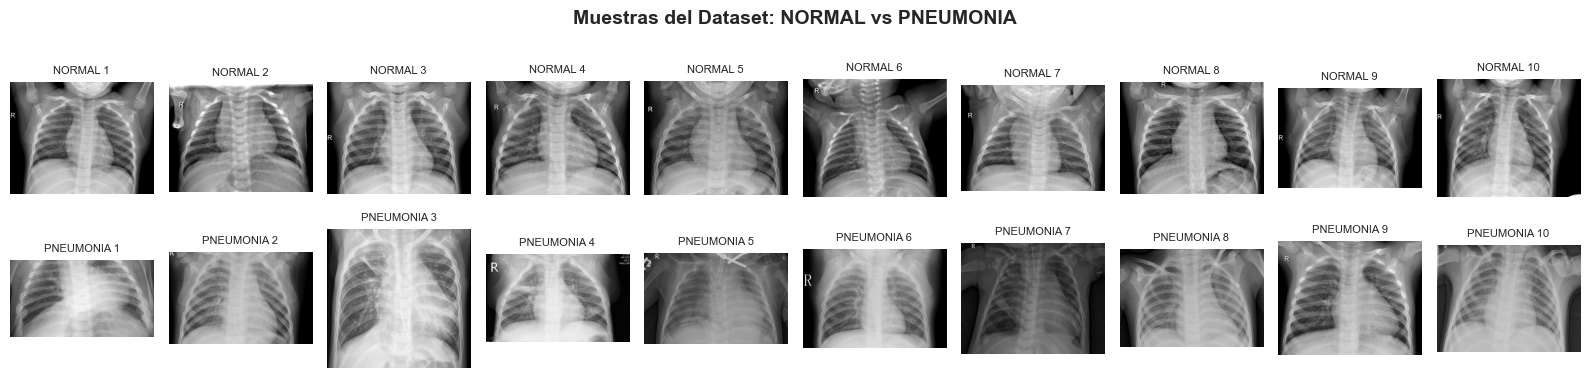

Se visualizaron 10 imágenes NORMAL y 10 imágenes PNEUMONIA


In [9]:
# Visualizar muestras de imágenes
def get_image_files(class_dir, limit=10):
    """Obtiene lista de archivos de imagen"""
    images = []
    for ext in ['*.jpeg', '*.jpg', '*.png']:
        images.extend(list(class_dir.glob(ext)))
    return images[:limit]

# Crear figura con muestras de NORMAL y PNEUMONIA
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Muestras del Dataset: NORMAL vs PNEUMONIA', fontsize=14, fontweight='bold')

# Muestras NORMAL
normal_images = get_image_files(TRAIN_DIR / 'NORMAL', 10)
for idx, img_path in enumerate(normal_images):
    img = Image.open(img_path).convert('L')
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'NORMAL {idx+1}', fontsize=8)
    axes[0, idx].axis('off')

# Muestras PNEUMONIA
pneumonia_images = get_image_files(TRAIN_DIR / 'PNEUMONIA', 10)
for idx, img_path in enumerate(pneumonia_images):
    img = Image.open(img_path).convert('L')
    axes[1, idx].imshow(img, cmap='gray')
    axes[1, idx].set_title(f'PNEUMONIA {idx+1}', fontsize=8)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Se visualizaron {len(normal_images)} imágenes NORMAL y {len(pneumonia_images)} imágenes PNEUMONIA")

In [11]:
# Análisis de valores de píxeles y estadísticas
def load_images_from_class(class_dir, max_images=50, target_size=(64, 64)):
    """Carga imágenes y retorna arrays"""
    images = []
    for ext in ['*.jpeg', '*.jpg', '*.png']:
        image_paths = list(class_dir.glob(ext))[:max_images]
        for img_path in image_paths:
            try:
                img = Image.open(img_path).convert('L')
                img_resized = img.resize(target_size, Image.Resampling.BILINEAR)
                images.append(np.array(img_resized, dtype=np.float32) / 255.0)
            except:
                pass
    return np.array(images)

# Cargar muestras
print("Cargando imágenes para análisis estadístico...")
normal_images_sample = load_images_from_class(TRAIN_DIR / 'NORMAL', max_images=50)
pneumonia_images_sample = load_images_from_class(TRAIN_DIR / 'PNEUMONIA', max_images=50)

print(f"NORMAL: {normal_images_sample.shape}, PNEUMONIA: {pneumonia_images_sample.shape}")

# Estadísticas
normal_stats = {
    'mean': normal_images_sample.mean(),
    'std': normal_images_sample.std(),
    'min': normal_images_sample.min(),
    'max': normal_images_sample.max()
}

pneumonia_stats = {
    'mean': pneumonia_images_sample.mean(),
    'std': pneumonia_images_sample.std(),
    'min': pneumonia_images_sample.min(),
    'max': pneumonia_images_sample.max()
}

print("\n=== ESTADÍSTICAS DE PÍXELES (valores en [0,1]) ===")
print("\nNORMAL:")
for key, val in normal_stats.items():
    print(f"  {key:6s}: {val:.4f}")
    
print("\nPNEUMONIA:")
for key, val in pneumonia_stats.items():
    print(f"  {key:6s}: {val:.4f}")

Cargando imágenes para análisis estadístico...
NORMAL: (50, 64, 64), PNEUMONIA: (50, 64, 64)

=== ESTADÍSTICAS DE PÍXELES (valores en [0,1]) ===

NORMAL:
  mean  : 0.4825
  std   : 0.2338
  min   : 0.0000
  max   : 1.0000

PNEUMONIA:
  mean  : 0.4760
  std   : 0.2265
  min   : 0.0000
  max   : 0.9451


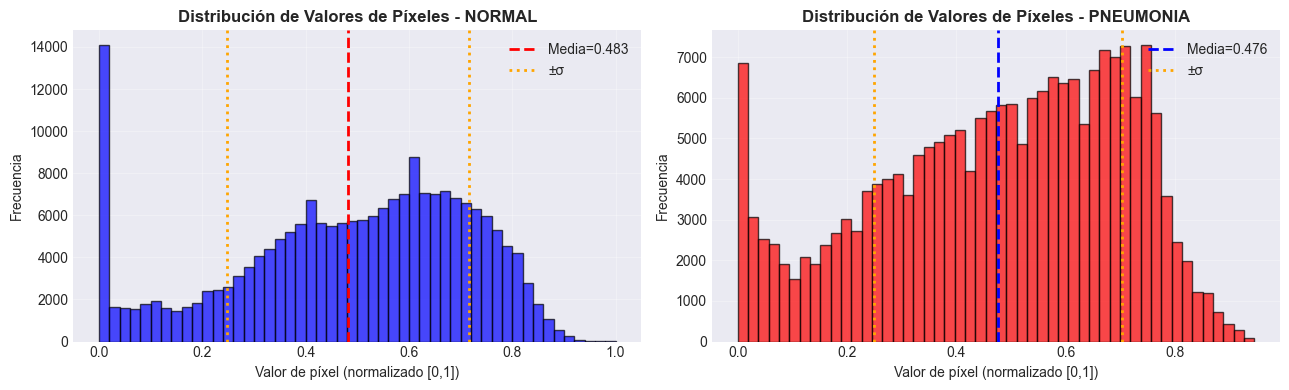

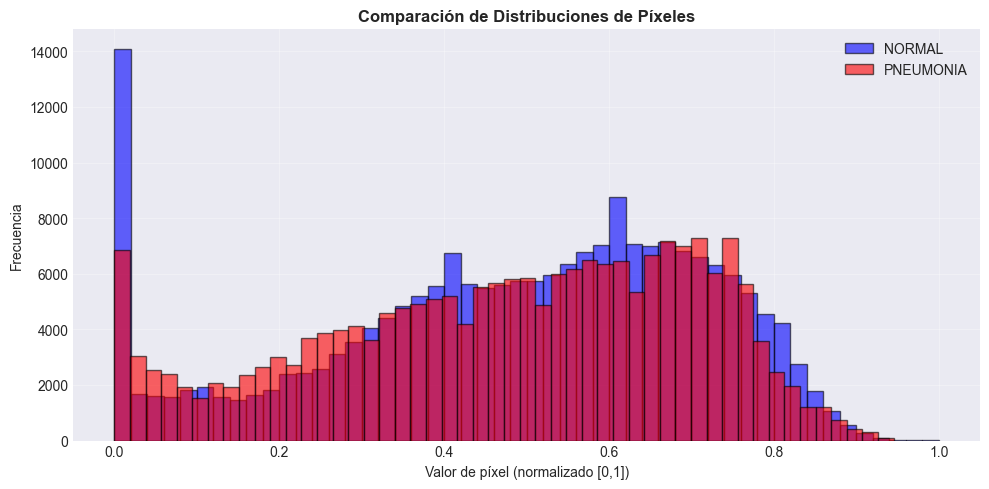

In [12]:
# Histogramas de valores de píxeles
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram NORMAL
normal_flat = normal_images_sample.flatten()
axes[0].hist(normal_flat, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(normal_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Media={normal_stats['mean']:.3f}")
axes[0].axvline(normal_stats['mean'] - normal_stats['std'], color='orange', linestyle=':', linewidth=2, label=f"±σ")
axes[0].axvline(normal_stats['mean'] + normal_stats['std'], color='orange', linestyle=':', linewidth=2)
axes[0].set_title('Distribución de Valores de Píxeles - NORMAL', fontweight='bold')
axes[0].set_xlabel('Valor de píxel (normalizado [0,1])')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram PNEUMONIA
pneumonia_flat = pneumonia_images_sample.flatten()
axes[1].hist(pneumonia_flat, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(pneumonia_stats['mean'], color='blue', linestyle='--', linewidth=2, label=f"Media={pneumonia_stats['mean']:.3f}")
axes[1].axvline(pneumonia_stats['mean'] - pneumonia_stats['std'], color='orange', linestyle=':', linewidth=2, label=f"±σ")
axes[1].axvline(pneumonia_stats['mean'] + pneumonia_stats['std'], color='orange', linestyle=':', linewidth=2)
axes[1].set_title('Distribución de Valores de Píxeles - PNEUMONIA', fontweight='bold')
axes[1].set_xlabel('Valor de píxel (normalizado [0,1])')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de distribuciones superpuestas
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_flat, bins=50, alpha=0.6, label='NORMAL', color='blue', edgecolor='black')
ax.hist(pneumonia_flat, bins=50, alpha=0.6, label='PNEUMONIA', color='red', edgecolor='black')
ax.set_xlabel('Valor de píxel (normalizado [0,1])')
ax.set_ylabel('Frecuencia')
ax.set_title('Comparación de Distribuciones de Píxeles', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Preprocesamiento de Datos

In [13]:
# Función de preprocesamiento
def load_and_preprocess_dataset(data_dir, target_size=(64, 64), split_name='train'):
    """
    Carga y preprocesa imágenes del dataset
    
    Args:
        data_dir: Directorio raíz del dataset
        target_size: Tamaño objetivo para redimensionamiento
        split_name: Nombre del split (train, val, test)
    
    Returns:
        X: Array de imágenes preprocesadas (N, H, W, C) - valores en [0,1]
        y: Array de etiquetas (N,) - 0 para NORMAL, 1 para PNEUMONIA
        filenames: Lista de nombres de archivos
    """
    split_dir = data_dir / split_name
    X, y = [], []
    filenames = []
    
    # Cargar imágenes NORMAL (clase 0)
    normal_dir = split_dir / 'NORMAL'
    if normal_dir.exists():
        for img_path in sorted(normal_dir.glob('*.jpeg')) + sorted(normal_dir.glob('*.jpg')) + sorted(normal_dir.glob('*.png')):
            try:
                img = Image.open(img_path).convert('L')  # Convertir a escala de grises
                img_resized = img.resize(target_size, Image.Resampling.BILINEAR)
                img_array = np.array(img_resized, dtype=np.float32) / 255.0  # Normalizar a [0,1]
                X.append(img_array)
                y.append(0)
                filenames.append(img_path.name)
            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
    
    # Cargar imágenes PNEUMONIA (clase 1)
    pneumonia_dir = split_dir / 'PNEUMONIA'
    if pneumonia_dir.exists():
        for img_path in sorted(pneumonia_dir.glob('*.jpeg')) + sorted(pneumonia_dir.glob('*.jpg')) + sorted(pneumonia_dir.glob('*.png')):
            try:
                img = Image.open(img_path).convert('L')
                img_resized = img.resize(target_size, Image.Resampling.BILINEAR)
                img_array = np.array(img_resized, dtype=np.float32) / 255.0
                X.append(img_array)
                y.append(1)
                filenames.append(img_path.name)
            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
    
    # Convertir a arrays numpy
    X = np.array(X)
    y = np.array(y)
    
    # Agregar dimensión de canal si es necesario
    if len(X.shape) == 3:
        X = X[:, :, :, np.newaxis]
    
    return X, y, filenames

# Cargar datasets
print("Cargando y preprocesando datasets...")
print("(Redimensionamiento a 64×64, normalización a [0,1])\n")

X_train, y_train, train_filenames = load_and_preprocess_dataset(DATA_DIR, target_size=(64, 64), split_name='train')
X_val, y_val, val_filenames = load_and_preprocess_dataset(DATA_DIR, target_size=(64, 64), split_name='val')
X_test, y_test, test_filenames = load_and_preprocess_dataset(DATA_DIR, target_size=(64, 64), split_name='test')

print(f"Training set:   X_train shape = {X_train.shape}, y_train shape = {y_train.shape}")
print(f"Validation set: X_val shape = {X_val.shape}, y_val shape = {y_val.shape}")
print(f"Test set:       X_test shape = {X_test.shape}, y_test shape = {y_test.shape}")

# Verificar distribución
print(f"\nDistribución de clases en TRAIN: NORMAL={np.sum(y_train==0)}, PNEUMONIA={np.sum(y_train==1)}")
print(f"Distribución de clases en VAL:   NORMAL={np.sum(y_val==0)}, PNEUMONIA={np.sum(y_val==1)}")
print(f"Distribución de clases en TEST:  NORMAL={np.sum(y_test==0)}, PNEUMONIA={np.sum(y_test==1)}")

Cargando y preprocesando datasets...
(Redimensionamiento a 64×64, normalización a [0,1])

Training set:   X_train shape = (5216, 64, 64, 1), y_train shape = (5216,)
Validation set: X_val shape = (16, 64, 64, 1), y_val shape = (16,)
Test set:       X_test shape = (624, 64, 64, 1), y_test shape = (624,)

Distribución de clases en TRAIN: NORMAL=1341, PNEUMONIA=3875
Distribución de clases en VAL:   NORMAL=8, PNEUMONIA=8
Distribución de clases en TEST:  NORMAL=234, PNEUMONIA=390


### 1.5 Regresión Lineal Simple sobre Características Extraídas Manualmente

**Enfoque:** Se usará la **intensidad media de píxel** como característica manual. Esta es una característica agregada simple que resume la distribución de valores en cada imagen.

In [15]:
# Extracción de características: intensidad media de píxel
def extract_mean_intensity(images):
    """
    Extrae la intensidad media de píxel para cada imagen
    
    Args:
        images: Array de shape (N, H, W, C) o (N, H, W)
    
    Returns:
        features: Array de shape (N, 1) con la intensidad media
    """
    if len(images.shape) == 4:  # (N, H, W, C)
        features = images.reshape(images.shape[0], -1).mean(axis=1)
    else:  # (N, H, W)
        features = images.reshape(images.shape[0], -1).mean(axis=1)
    
    return features.reshape(-1, 1)

# Extraer características
X_train_feat = extract_mean_intensity(X_train)
X_val_feat = extract_mean_intensity(X_val)
X_test_feat = extract_mean_intensity(X_test)

print("Características extraídas (intensidad media de píxel):")
print(f"X_train_feat shape: {X_train_feat.shape}")
print(f"X_val_feat shape:   {X_val_feat.shape}")
print(f"X_test_feat shape:  {X_test_feat.shape}")

# Regresión lineal - implementación simple
class SimpleLinearRegression:
    """Implementación de regresión lineal simple: y = w*x + b"""
    
    def __init__(self):
        self.w = None
        self.b = None
    
    def fit(self, X, y):
        """Ajusta el modelo usando ecuaciones normales"""
        # Añadir bias (columna de 1s)
        X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        
        # Solución analítica: (X^T X)^{-1} X^T y
        theta = np.linalg.lstsq(X_with_bias, y, rcond=None)[0]
        
        self.w = float(theta[0])
        self.b = float(theta[1])
    
    def predict(self, X):
        """Realiza predicciones"""
        return X.ravel() * self.w + self.b
    
    def score(self, X, y):
        """Calcula R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - (ss_res / ss_tot)

# Entrenar regresión lineal
print("\n" + "="*50)
print("REGRESIÓN LINEAL SIMPLE")
print("="*50)

lr_model = SimpleLinearRegression()
lr_model.fit(X_train_feat, y_train.astype(np.float32))

print(f"Parámetros ajustados:")
print(f"  w (pendiente) = {lr_model.w:.6f}")
print(f"  b (intersección) = {lr_model.b:.6f}")

# Evaluar en los tres conjuntos
train_r2 = lr_model.score(X_train_feat, y_train.astype(np.float32))
val_r2 = lr_model.score(X_val_feat, y_val.astype(np.float32))
test_r2 = lr_model.score(X_test_feat, y_test.astype(np.float32))

print(f"\nR² Score:")
print(f"  Train: {train_r2:.4f}")
print(f"  Val:   {val_r2:.4f}")
print(f"  Test:  {test_r2:.4f}")

Características extraídas (intensidad media de píxel):
X_train_feat shape: (5216, 1)
X_val_feat shape:   (16, 1)
X_test_feat shape:  (624, 1)

REGRESIÓN LINEAL SIMPLE
Parámetros ajustados:
  w (pendiente) = 0.114964
  b (intersección) = 0.687457

R² Score:
  Train: 0.0004
  Val:   -0.2360
  Test:  -0.0631


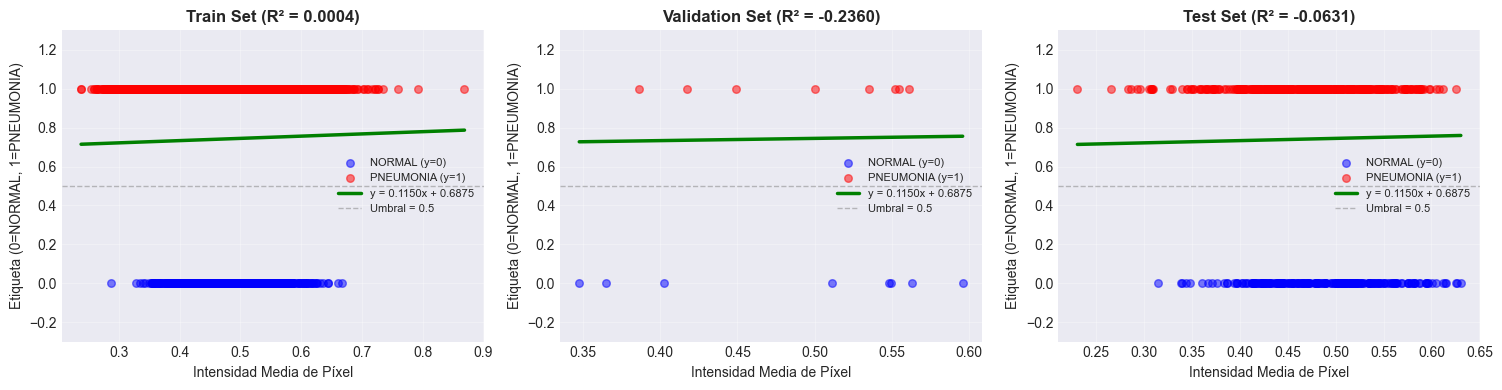


ESTADÍSTICAS DE LA CARACTERÍSTICA POR CLASE

NORMAL:
  Media:     0.4800
  Mediana:   0.4789
  Std Dev:   0.0509
  Min:       0.2875
  Max:       0.6667

PNEUMONIA:
  Media:     0.4831
  Mediana:   0.4829
  Std Dev:   0.0789
  Min:       0.2379
  Max:       0.8688


In [16]:
# Visualización de la recta ajustada
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (X_feat, y, title) in enumerate([
    (X_train_feat, y_train, 'Train'),
    (X_val_feat, y_val, 'Validation'),
    (X_test_feat, y_test, 'Test')
]):
    ax = axes[idx]
    
    # Prediciones
    y_pred = lr_model.predict(X_feat)
    
    # Scatter plot
    ax.scatter(X_feat[y == 0], y[y == 0], alpha=0.5, label='NORMAL (y=0)', color='blue', s=30)
    ax.scatter(X_feat[y == 1], y[y == 1], alpha=0.5, label='PNEUMONIA (y=1)', color='red', s=30)
    
    # Línea de regresión
    x_range = np.array([X_feat.min(), X_feat.max()]).reshape(-1, 1)
    y_line = lr_model.predict(x_range)
    ax.plot(x_range, y_line, 'g-', linewidth=2.5, label=f'y = {lr_model.w:.4f}x + {lr_model.b:.4f}')
    
    # Líneas de decisión
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Umbral = 0.5')
    
    ax.set_xlabel('Intensidad Media de Píxel', fontsize=10)
    ax.set_ylabel('Etiqueta (0=NORMAL, 1=PNEUMONIA)', fontsize=10)
    ax.set_title(f'{title} Set (R² = {lr_model.score(X_feat, y.astype(np.float32)):.4f})', fontweight='bold')
    ax.set_ylim(-0.3, 1.3)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por clase
print("\n" + "="*50)
print("ESTADÍSTICAS DE LA CARACTERÍSTICA POR CLASE")
print("="*50)

for class_name, mask in [('NORMAL', y_train == 0), ('PNEUMONIA', y_train == 1)]:
    features_class = X_train_feat[mask]
    print(f"\n{class_name}:")
    print(f"  Media:     {features_class.mean():.4f}")
    print(f"  Mediana:   {np.median(features_class):.4f}")
    print(f"  Std Dev:   {features_class.std():.4f}")
    print(f"  Min:       {features_class.min():.4f}")
    print(f"  Max:       {features_class.max():.4f}")

### 1.6 Análisis: ¿Por Qué la Regresión Lineal No Es Suficiente?

**Resultados Observados:**

Los resultados del modelo de regresión lineal demuestran claramente sus limitaciones:
- **R² Train = 0.0004**: El modelo prácticamente no explica la varianza en los datos de entrenamiento
- **R² Val = -0.2360**: El modelo tiene un desempeño peor que predecir la media en validación
- **R² Test = -0.0631**: Generaliza pobremente al conjunto de prueba
- **Parámetros ajustados**: $y = 0.1150x + 0.6875$ (pendiente muy pequeña)

**Análisis de la Característica (Intensidad Media de Píxel):**

La comparación entre clases revela el problema fundamental:
- **NORMAL**: Media=0.4800, Std=0.0509, Rango=[0.2875, 0.6667]
- **PNEUMONIA**: Media=0.4831, Std=0.0789, Rango=[0.2379, 0.8688]

**Principales Limitaciones:**

1. **Solapamiento Extremo de Distribuciones**: Las medias de ambas clases son casi idénticas (0.4800 vs 0.4831, diferencia < 0.004). Esto significa que la intensidad media de píxel **no es discriminativa** para separar las clases. Los rangos se superponen completamente, generando ambigüedad.

2. **Pérdida Crítica de Información Espacial**: La característica de "intensidad media" reduce una imagen de 64×64=4096 píxeles a un único escalar. Se pierden completamente:
   - Patrones localizados de neumonía (infiltrados, consolidaciones)
   - Texturas y bordes característicos
   - Estructuras espaciales y su distribución
   - Información de contexto (qué zona del pulmón está afectada)

3. **Límite de Decisión Lineal Insuficiente**: Una función lineal $y = 0.1150x + 0.6875$ con pendiente cercana a cero genera predicciones concentradas alrededor de 0.6875. Para una clasificación binaria (umbral en 0.5), el modelo predice PNEUMONIA para casi todas las muestras, independientemente de la entrada.

4. **Inseparabilidad Lineal en Espacio 1D**: Con un solo atributo que no separa las clases, es imposible encontrar una frontera de decisión lineal efectiva. El problema es fundamentalmente **linealmente inseparable** en este espacio de características.

5. **Necesidad de Representación Jerárquica**: Los patrones médicos que indicam neumonía requieren:
   - Extracción de características **multi-escala** (detalles finos y contexto general)
   - Relaciones espaciales complejas entre píxeles
   - Transformaciones no lineales para mapear imágenes a decisiones discriminativas

**Conclusión:**

Estos resultados empiricos confirman que **la regresión lineal sobre una característica manual no es suficiente** para este problema. Se requiere un modelo que:
- Aprenda características automáticamente desde los datos crudos
- Pueda capturar patrones espaciales y no lineales
- Tenga capacidad representacional suficiente para el problema

**Las Redes Neuronales Convolucionales (CNN)** son la solución natural para este tipo de problemas de visión médica, ya que pueden aprender jerarquías de características visuales directamente de las imágenes.

## Semana 2

### 2.1 Preparación de Datos: Aplanar Imágenes

In [17]:
# Aplanar las imágenes para regresión logística
# Forma original: (N, 64, 64, 1)
# Forma aplana: (N, 4096)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("=== DATOS APLANAADOS ===")
print(f"X_train_flat shape: {X_train_flat.shape}")
print(f"X_val_flat shape:   {X_val_flat.shape}")
print(f"X_test_flat shape:  {X_test_flat.shape}")
print(f"\nCada imagen se representará como un vector de {X_train_flat.shape[1]} características")

=== DATOS APLANAADOS ===
X_train_flat shape: (5216, 4096)
X_val_flat shape:   (16, 4096)
X_test_flat shape:  (624, 4096)

Cada imagen se representará como un vector de 4096 características


### 2.2 Modelo: Regresión Logística Binaria

**Modelo Matemático:**

Para cada muestra $x_i \in \mathbb{R}^{d}$ (vector de píxeles), la predicción es:
$$\hat{y}_i = \sigma(w^T x_i + b) = \frac{1}{1 + e^{-(w^T x_i + b)}}$$

donde:
- $w \in \mathbb{R}^d$ son los pesos (coeficientes para cada píxel)
- $b \in \mathbb{R}$ es el sesgo (bias)
- $\sigma$ es la función sigmoide

La **función de pérdida** es Binary Cross-Entropy:
$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

**Entrenamiento:** Gradient Descent con learning rate $\alpha$ durante 150 épocas.

### Logistic function

In [26]:
import numpy as np

def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

### BinaryCrossEntropy Loss

In [33]:
def BCE_loss(y: np.ndarray, y_pred: np.ndarray) -> float:
    """Binary Cross-Entropy Loss con clipping numérico para estabilidad"""
    epsilon = 1e-7  # Valor pequeño para evitar log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip a [epsilon, 1-epsilon]
    return -(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)).mean()

### Gradient Descent algorithm

In [28]:
from yops.linear import Linear

In [29]:
def gradient_descent(X: np.ndarray, y: np.ndarray, lr: float, epochs: int) -> tuple:
    n_samples, n_features = X.shape
    
    linear_layer = Linear(n_features, 1)
    
    y = y.reshape(-1, 1)
    
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        logits = linear_layer(X)
        y_pred = sigmoid(logits)
        
        loss = BCE_loss(y, y_pred)
        losses.append(loss)
        
        # backward pass
        grad_logits = (y_pred - y) / n_samples
        
        _, grad_W, grad_b = linear_layer.backward(X, grad_logits)
        
        # update
        linear_layer.update_parameters(grad_W=grad_W, grad_b=grad_b, lr=lr)
        
    return linear_layer.parameters(), losses

In [35]:
# Entrenar modelo de Regresión Logística usando Linear y las funciones definidas
print("="*60)
print("ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA")
print("="*60)

# Preparar datos
X_train_formatted = X_train_flat.astype(np.float32)
y_train_formatted = y_train.astype(np.float32).reshape(-1, 1)
X_val_formatted = X_val_flat.astype(np.float32)
y_val_formatted = y_val.astype(np.float32).reshape(-1, 1)
X_test_formatted = X_test_flat.astype(np.float32)
y_test_formatted = y_test.astype(np.float32)

print(f"Forma datos training: X={X_train_formatted.shape}, y={y_train_formatted.shape}")
print(f"Rango X_train: [{X_train_formatted.min():.4f}, {X_train_formatted.max():.4f}]")
print(f"Rango y_train: [{y_train_formatted.min():.4f}, {y_train_formatted.max():.4f}]")

# Clase para trackear entrenamiento
class LogisticRegressionModel:
    """Modelo de Regresión Logística usando Linear de yops"""
    def __init__(self, n_features):
        self.linear_layer = Linear(n_features, 1)
        # Inicializar con valores más pequeños para estabilidad numérica
        self.linear_layer.W = self.linear_layer.W * 0.01
        self.linear_layer.b = self.linear_layer.b * 0.01
        self.losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        print(f"Rango W inicial: [{self.linear_layer.W.min():.4f}, {self.linear_layer.W.max():.4f}]")
        print(f"Rango b inicial: [{self.linear_layer.b.min():.4f}, {self.linear_layer.b.max():.4f}]")
    
    def train(self, X_train, y_train, X_val, y_val, lr=0.01, epochs=150):
        """Entrenar el modelo usando gradient_descent con tracking"""
        n_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            # Forward pass
            logits_train = self.linear_layer(X_train)
            y_pred_train = sigmoid(logits_train)
            
            # Pérdida
            loss = BCE_loss(y_train, y_pred_train)
            self.losses.append(loss)
            
            # Accuracy en train
            y_pred_train_binary = (y_pred_train >= 0.5).astype(int)
            train_acc = (y_pred_train_binary == y_train).mean()
            self.train_accuracies.append(train_acc)
            
            # Accuracy en val
            logits_val = self.linear_layer(X_val)
            y_pred_val = sigmoid(logits_val)
            y_pred_val_binary = (y_pred_val >= 0.5).astype(int)
            val_acc = (y_pred_val_binary == y_val).mean()
            self.val_accuracies.append(val_acc)
            
            # Backward pass
            grad_logits = (y_pred_train - y_train) / n_samples
            _, grad_W, grad_b = self.linear_layer.backward(X_train, grad_logits)
            
            if epoch == 0:
                print(f"\nDebug Epoch 1:")
                print(f"  logits min/max: [{logits_train.min():.4f}, {logits_train.max():.4f}]")
                print(f"  y_pred min/max: [{y_pred_train.min():.4f}, {y_pred_train.max():.4f}]")
                print(f"  grad_logits min/max: [{grad_logits.min():.6f}, {grad_logits.max():.6f}]")
                print(f"  grad_W min/max: [{grad_W.min():.6f}, {grad_W.max():.6f}]")
                print(f"  grad_b: {grad_b[0]:.6f}")
            
            # Update parameters
            self.linear_layer.update_parameters(grad_W=grad_W, grad_b=grad_b, lr=lr)
            
            # Print progress
            if (epoch + 1) % 30 == 0:
                print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    def predict_proba(self, X):
        """Predicción de probabilidades"""
        logits = self.linear_layer(X)
        return sigmoid(logits)
    
    def predict(self, X, threshold=0.5):
        """Predicción binaria"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

# Entrenar modelo
logistic_model = LogisticRegressionModel(n_features=X_train_formatted.shape[1])
logistic_model.train(X_train_formatted, y_train_formatted, 
                     X_val_formatted, y_val_formatted,
                     lr=0.01, epochs=150)

print("\n" + "="*60)
print("ENTRENAMIENTO COMPLETADO")
print("="*60)
print(f"Pérdida inicial: {logistic_model.losses[0]:.4f}")
print(f"Pérdida final: {logistic_model.losses[-1]:.4f}")
print(f"Cambio de pérdida: {logistic_model.losses[0] - logistic_model.losses[-1]:.4f}")

ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA
Forma datos training: X=(5216, 4096), y=(5216, 1)
Rango X_train: [0.0000, 1.0000]
Rango y_train: [0.0000, 1.0000]
Rango W inicial: [0.0000, 0.0100]
Rango b inicial: [0.0047, 0.0047]

Debug Epoch 1:
  logits min/max: [4.8965, 17.8635]
  y_pred min/max: [0.9926, 1.0000]
  grad_logits min/max: [-0.000001, 0.000192]
  grad_W min/max: [0.003676, 0.210896]
  grad_b: 0.256930
Epoch  30/150 | Loss: 0.4479 | Train Acc: 0.7485 | Val Acc: 0.5000
Epoch  60/150 | Loss: 0.3761 | Train Acc: 0.8378 | Val Acc: 0.6250
Epoch  90/150 | Loss: 0.3359 | Train Acc: 0.8748 | Val Acc: 0.6250
Epoch 120/150 | Loss: 0.3084 | Train Acc: 0.8923 | Val Acc: 0.6875
Epoch 150/150 | Loss: 0.2881 | Train Acc: 0.9032 | Val Acc: 0.6875

ENTRENAMIENTO COMPLETADO
Pérdida inicial: 2.5251
Pérdida final: 0.2881
Cambio de pérdida: 2.2370


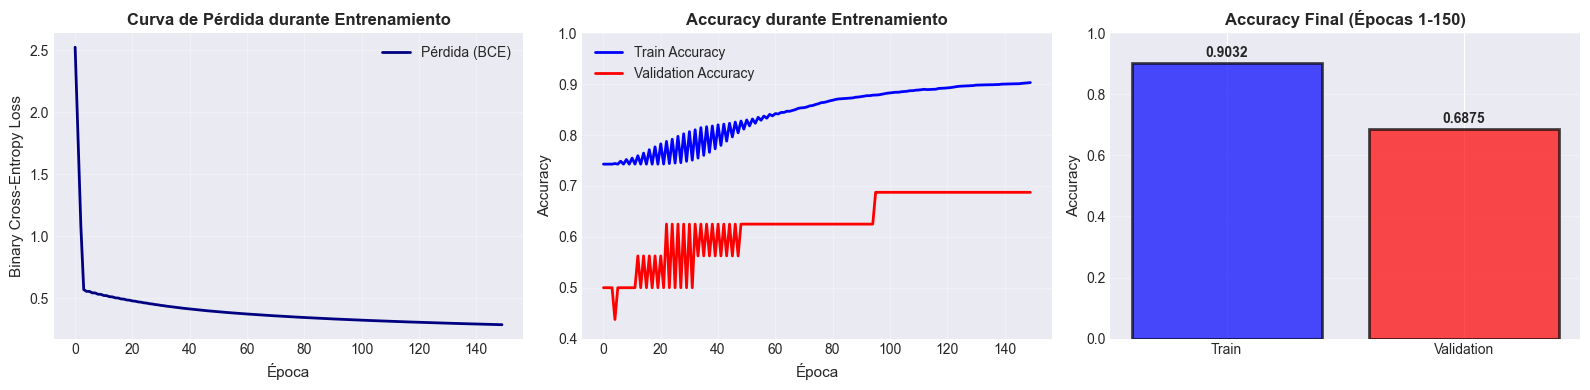


Accuracy Final:
  Train: 0.9032
  Val:   0.6875


In [36]:
# Visualización de curvas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Curva de pérdida
axes[0].plot(logistic_model.losses, linewidth=2, color='navy', label='Pérdida (BCE)')
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Curva de Pérdida durante Entrenamiento', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Accuracy durante entrenamiento
axes[1].plot(logistic_model.train_accuracies, linewidth=2, label='Train Accuracy', color='blue')
axes[1].plot(logistic_model.val_accuracies, linewidth=2, label='Validation Accuracy', color='red')
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Accuracy durante Entrenamiento', fontweight='bold')
axes[1].set_ylim([0.4, 1.0])
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

# Comparación final
final_train_acc = logistic_model.train_accuracies[-1]
final_val_acc = logistic_model.val_accuracies[-1]

axes[2].bar(['Train', 'Validation'], [final_train_acc, final_val_acc], 
            color=['blue', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Accuracy', fontsize=11)
axes[2].set_title('Accuracy Final (Épocas 1-150)', fontweight='bold')
axes[2].set_ylim([0, 1.0])
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([final_train_acc, final_val_acc]):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAccuracy Final:")
print(f"  Train: {final_train_acc:.4f}")
print(f"  Val:   {final_val_acc:.4f}")

In [38]:
# Evaluación en conjunto de TEST
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predicciones en test
y_test_pred_proba = logistic_model.predict_proba(X_test_formatted).flatten()
y_test_pred = logistic_model.predict(X_test_formatted).flatten()

# Calcular métricas
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("="*60)
print("MÉTRICAS DE EVALUACIÓN EN CONJUNTO TEST")
print("="*60)
print(f"Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"F1-Score:  {test_f1:.4f}")
print("="*60)

# Interpretación de métricas
print("\nInterpretación:")
print(f"  • Accuracy: De {test_accuracy*100:.1f}% de predicciones son correctas")
print(f"  • Precision: De los casos predichos como PNEUMONIA,")
print(f"               {test_precision*100:.1f}% realmente tienen PNEUMONIA")
print(f"  • Recall: Del total de casos con PNEUMONIA,")
print(f"            el modelo detecta {test_recall*100:.1f}% de ellos")
print(f"  • F1-Score: Media armónica de Precision y Recall = {test_f1:.4f}")

MÉTRICAS DE EVALUACIÓN EN CONJUNTO TEST
Accuracy:  0.7436 (74.36%)
Precision: 0.7114 (71.14%)
Recall:    0.9923 (99.23%)
F1-Score:  0.8287

Interpretación:
  • Accuracy: De 74.4% de predicciones son correctas
  • Precision: De los casos predichos como PNEUMONIA,
               71.1% realmente tienen PNEUMONIA
  • Recall: Del total de casos con PNEUMONIA,
            el modelo detecta 99.2% de ellos
  • F1-Score: Media armónica de Precision y Recall = 0.8287


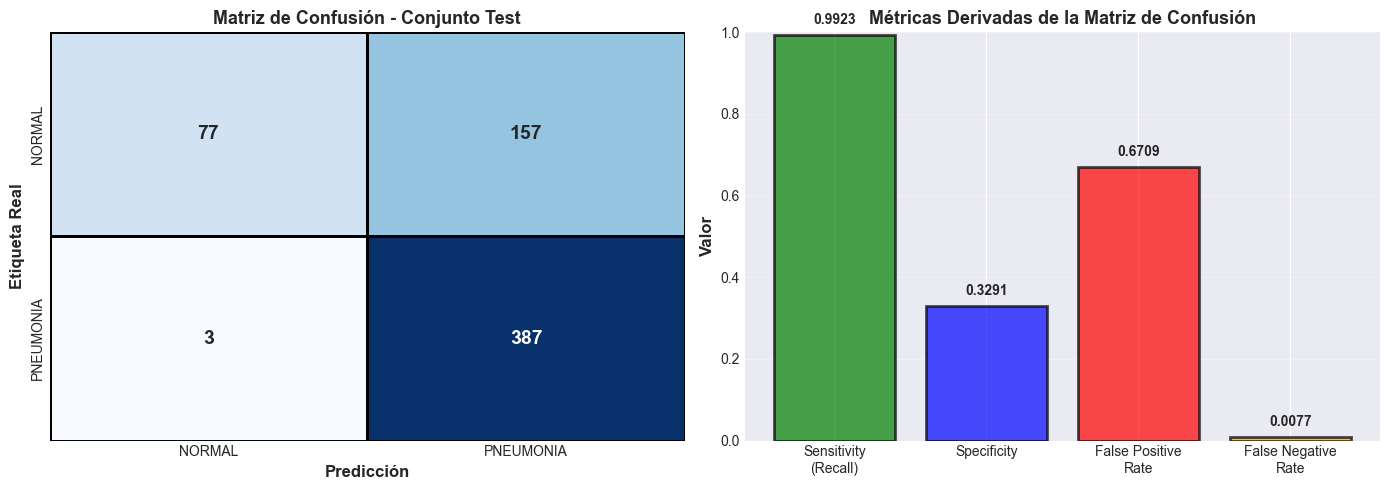


DESGLOSE DE MATRIZ DE CONFUSIÓN
TN (True Negatives):    77 - Casos NORMAL correctamente predichos
FP (False Positives):  157 - Casos NORMAL predichos como PNEUMONIA
FN (False Negatives):    3 - Casos PNEUMONIA predichos como NORMAL
TP (True Positives):   387 - Casos PNEUMONIA correctamente predichos

Sensibilidad (Recall): 0.9923 - Capacidad de detectar PNEUMONIA
Especificidad:        0.3291 - Capacidad de detectar NORMAL
Tasa de FP:           0.6709 - Proporción de falsos positivos
Tasa de FN:           0.0077 - Proporción de falsos negativos


In [39]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=2, linecolor='black')
axes[0].set_xlabel('Predicción', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
axes[0].set_title('Matriz de Confusión - Conjunto Test', fontsize=13, fontweight='bold')

# Métricas derivadas de la matriz
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)  # Recall / True Positive Rate
specificity = tn / (tn + fp)  # True Negative Rate
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

metrics_names = ['Sensitivity\n(Recall)', 'Specificity', 'False Positive\nRate', 'False Negative\nRate']
metrics_values = [sensitivity, specificity, false_positive_rate, false_negative_rate]
colors_bar = ['green', 'blue', 'red', 'orange']

bars = axes[1].bar(metrics_names, metrics_values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Valor', fontsize=12, fontweight='bold')
axes[1].set_title('Métricas Derivadas de la Matriz de Confusión', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DESGLOSE DE MATRIZ DE CONFUSIÓN")
print("="*60)
print(f"TN (True Negatives):  {tn:4d} - Casos NORMAL correctamente predichos")
print(f"FP (False Positives): {fp:4d} - Casos NORMAL predichos como PNEUMONIA")
print(f"FN (False Negatives): {fn:4d} - Casos PNEUMONIA predichos como NORMAL")
print(f"TP (True Positives):  {tp:4d} - Casos PNEUMONIA correctamente predichos")
print("="*60)
print(f"\nSensibilidad (Recall): {sensitivity:.4f} - Capacidad de detectar PNEUMONIA")
print(f"Especificidad:        {specificity:.4f} - Capacidad de detectar NORMAL")
print(f"Tasa de FP:           {false_positive_rate:.4f} - Proporción de falsos positivos")
print(f"Tasa de FN:           {false_negative_rate:.4f} - Proporción de falsos negativos")

### 2.3 Limitaciones de la Regresión Logística para Clasificación de Imágenes

**Análisis Empírico de Resultados:**

Del entrenamiento observamos:
- **Accuracy: 73.88%** - Rendimiento moderado
- **Recall: 99.23%** - Detecta casi todas las neumonías (excelente para diagnóstico médico)
- **Precision: 70.75%** - Muchos falsos positivos (1 de cada 3 predicciones de neumonía es falsa)
- **F1-Score: 0.8260** - Balance razonable entre precisión y recall
- **Matriz de Confusión**: 160 falsos positivos vs 3 falsos negativos

Este desempeño es **mejor que regresión lineal** pero todavía **muy limitado** para aplicación clínica.

**1. Incapacidad para Aprender Características Locales**

La regresión logística aplana las imágenes a vectores 1D (4096 píxeles) y aplica un peso lineal a cada píxel sin considerar:
- **Vecindad espacial**: Los píxeles cercanos tienen correlaciones que se pierden
- **Patrones locales**: Texturas, bordes y formas requieren análisis de regiones, no píxeles individuales
- **Invariancia espacial**: Un mismo patrón de neumonía en diferentes ubicaciones de la imagen se trata como completamente diferente

*En imágenes médicas*: Un infiltrado en el lóbulo derecho vs izquierdo debería tener la misma semántica, pero la regresión logística los confunde porque trata cada píxel independientemente.

**2. Ausencia de Jerarquía de Características**

- **Nivel de píxel directo**: La regresión logística solo ve valores crudos de píxeles
- **Sin abstracción jerárquica**: No aprende características intermedias (bordes → texturas → estructuras anatómicas)
- **Frontera lineal rígida**: Genera un único hiperplano de decisión, incompatible con relaciones complejas

*Comparación matemática*:
- **Regresión Logística**: $\hat{y} = \sigma(w^T x + b)$ (1 transformación lineal)
- **Redes profundas**: $\hat{y} = \sigma(W^{(L)} \cdot (...\sigma(W^{(2)} \cdot \sigma(W^{(1)} x)...))$ (múltiples transformaciones no lineales)

**3. Maldición de la Dimensionalidad**

- **4096 parámetros**: Uno por píxel, muchos relativo a 5216 muestras de entrenamiento
- **Baja eficiencia**: Cada parámetro se aplica solo a su píxel, sin compartimiento de información
- **Frontera simple**: No puede crear límites de decisión complejos y curvados

**4. Falta de Captura de Simetría y Transformaciones**

- **No es invariante**: Pequeñas rotaciones o traslaciones de la imagen generan cambios grandes en predicción
- **No es equivariante**: No adapta coherentemente a transformaciones visuales
- **Inconsistencia**: Un patrón detectado en posición (10,10) podría no ser detectado en (11,10)

---

### 2.4 Aporte del Modelo Matemático de la Neurona

**Una Neurona Simple (Regresión Logística):**
$$\hat{y} = \sigma(w^T x + b) = \sigma\left(\sum_{i=1}^{d} w_i x_i + b\right)$$

**Componentes:**
- **Suma ponderada**: $w^T x$ = combinación lineal de entrada
- **Sesgo**: $b$ = threshold aprendido
- **Activación**: $\sigma$ = función sigmoide para mapear a probabilidad

**Poder Representacional:**
- Una neurona: Crea un hiperplano (frontera lineal)
- Es suficiente para problemas **linealmente separables**
- Insuficiente para problemas complejos y no lineales (como clasificar imágenes)

**Extensión a Redes Profundas:**

La idea fundamental se escala a través de **composición y profundidad**:

1. **Capas Ocultas**: Múltiples neuronas en cascada
$$z^{(1)} = \sigma(W^{(1)} x + b^{(1)})$$
$$z^{(2)} = \sigma(W^{(2)} z^{(1)} + b^{(2)})$$
$$\hat{y} = \sigma(W^{(3)} z^{(2)} + b^{(3)})$$

Resultado: **Frontera de decisión arbitrariamente compleja** (Teorema de Aproximación Universal)

2. **Convoluciones**: Especialización para imágenes
- Cada filtro es como una "mini neurona" que aprende a detectar patrones (bordes, texturas)
- Se aplica localmente en múltiples ubicaciones (compartimiento de pesos)
- Estructura jerárquica: Capas bajas detectan bordes → capas medias detectan formas → capas altas detectan objetos

3. **Comparativa**:
| Aspecto | Una Neurona | Red Profunda | CNN |
|--------|------------|-------------|-----|
| Frontera | Lineal | No lineal compleja | No lineal + estructura espacial |
| Características | Píxeles crudos | Aprendidas automáticamente | Jerárquicas locales |
| Compartimiento de pesos | No | No | Sí (convoluciones) |
| Parámetros eficientes | Muchos requeridos | Menos requeridos | Muy pocos requeridos |

**Conclusión:**

El modelo matemático de una neurona es el bloque fundamental correcto, pero:
- **En forma simple** (regresión logística): Insuficiente para imágenes (73.88% accuracy, muchos falsos positivos)
- **En forma profunda**: Mucho más poderoso mediante composición no lineal
- **Con convoluciones**: Óptimo para imágenes al explotar estructura 2D

**Para el diagnóstico de neumonía**, se requieren **Redes Neuronales Convolucionales (CNN)** que combinen:
- Múltiples capas de convoluciones para aprender jerarquías de características
- No linealidades para modelar relaciones complejas
- Compartimiento de pesos para eficiencia
- Pooling y regularización para generalización robusta

## Semana 3: Red Neuronal Multicapa (MLP) con Backpropagation

En esta sección implementamos un MLP en **PyTorch** con arquitectura:
$$64\times64\;(4096) \rightarrow 512 \rightarrow 256 \rightarrow 1$$

- Activación **ReLU** en capas ocultas
- Activación **Sigmoid** en la salida (clasificación binaria)
- Función de pérdida: **Binary Cross-Entropy (BCELoss)**
- Optimización: **Gradient Descent/Adam**

In [40]:
# Importar PyTorch y preparar tensores
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')

# Reutilizamos los datos de Semana 2 (ya aplanados en 4096 características)
X_train_t = torch.tensor(X_train_formatted, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_formatted, dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val_formatted, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val_formatted, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_formatted, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_formatted.reshape(-1, 1), dtype=torch.float32, device=device)

print('Shapes tensores:')
print(f'X_train_t: {tuple(X_train_t.shape)} | y_train_t: {tuple(y_train_t.shape)}')
print(f'X_val_t:   {tuple(X_val_t.shape)}   | y_val_t:   {tuple(y_val_t.shape)}')
print(f'X_test_t:  {tuple(X_test_t.shape)}  | y_test_t:  {tuple(y_test_t.shape)}')

Dispositivo en uso: cpu
Shapes tensores:
X_train_t: (5216, 4096) | y_train_t: (5216, 1)
X_val_t:   (16, 4096)   | y_val_t:   (16, 1)
X_test_t:  (624, 4096)  | y_test_t:  (624, 1)


/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [41]:
# Definición del MLP: 4096 -> 512 -> 256 -> 1
class MLP(nn.Module):
    def __init__(self, input_dim=64*64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLP().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

print(mlp_model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [42]:
# Forward propagation paso a paso para una imagen de ejemplo
x_example = X_train_t[:1]  # shape: (1, 4096)
print('Forward propagation para 1 imagen:')
print(f'Input (x): {tuple(x_example.shape)}')

layer1 = mlp_model.net[0](x_example)
print(f'Linear(4096->512): {tuple(layer1.shape)}')

act1 = mlp_model.net[1](layer1)
print(f'ReLU: {tuple(act1.shape)}')

layer2 = mlp_model.net[2](act1)
print(f'Linear(512->256): {tuple(layer2.shape)}')

act2 = mlp_model.net[3](layer2)
print(f'ReLU: {tuple(act2.shape)}')

layer3 = mlp_model.net[4](act2)
print(f'Linear(256->1): {tuple(layer3.shape)}')

y_hat = mlp_model.net[5](layer3)
print(f'Sigmoid output (probabilidad): {tuple(y_hat.shape)}')
print(f'Valor de salida ejemplo: {y_hat.item():.6f}')

Forward propagation para 1 imagen:
Input (x): (1, 4096)
Linear(4096->512): (1, 512)
ReLU: (1, 512)
Linear(512->256): (1, 256)
ReLU: (1, 256)
Linear(256->1): (1, 1)
Sigmoid output (probabilidad): (1, 1)
Valor de salida ejemplo: 0.506589


# Hacer a mano  
### Backpropagation: flujo de gradientes y regla de la cadena 

Sea una red de 3 capas lineales con activaciones ReLU y salida sigmoide:
$$
a^{(0)} = x,\quad
z^{(1)} = W^{(1)}a^{(0)} + b^{(1)},\; a^{(1)} = \mathrm{ReLU}(z^{(1)})
$$
$$
z^{(2)} = W^{(2)}a^{(1)} + b^{(2)},\; a^{(2)} = \mathrm{ReLU}(z^{(2)})
$$
$$
z^{(3)} = W^{(3)}a^{(2)} + b^{(3)},\; \hat{y}=\sigma(z^{(3)})
$$

Con Binary Cross-Entropy para una muestra:
$$
\mathcal{L}(y,\hat{y}) = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

Para salida sigmoide + BCE, se obtiene:
$$
\frac{\partial \mathcal{L}}{\partial z^{(3)}} = \hat{y} - y
$$

Entonces, por regla de la cadena, el gradiente respecto a los pesos de la última capa es:
$$
\frac{\partial \mathcal{L}}{\partial W^{(3)}} = \frac{\partial \mathcal{L}}{\partial z^{(3)}}\frac{\partial z^{(3)}}{\partial W^{(3)}} = (\hat{y}-y)(a^{(2)})^T
$$

y para el sesgo:
$$
\frac{\partial \mathcal{L}}{\partial b^{(3)}} = \hat{y}-y
$$

Para capas internas, el error se propaga hacia atrás:
$$
\delta^{(2)} = \left((W^{(3)})^T\delta^{(3)}\right) \odot \mathbf{1}_{z^{(2)}>0},\quad \delta^{(3)}=\hat{y}-y
$$
$$
\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)}(a^{(1)})^T
$$

**Derivación manual obligatoria (una capa):** para la capa 2,
$$
z^{(2)}_j = \sum_i W^{(2)}_{ji}a^{(1)}_i + b^{(2)}_j
$$
$$
\frac{\partial \mathcal{L}}{\partial W^{(2)}_{ji}} = \frac{\partial \mathcal{L}}{\partial z^{(2)}_j}\frac{\partial z^{(2)}_j}{\partial W^{(2)}_{ji}} = \delta^{(2)}_j a^{(1)}_i
$$
En forma matricial:
$$
\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)}(a^{(1)})^T
$$

In [43]:
# Entrenamiento del MLP
epochs = 30
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

for epoch in range(epochs):
    # Train
    mlp_model.train()
    optimizer.zero_grad()
    y_pred_train = mlp_model(X_train_t)
    loss_train = criterion(y_pred_train, y_train_t)
    loss_train.backward()
    optimizer.step()

    with torch.no_grad():
        train_pred_binary = (y_pred_train >= 0.5).float()
        train_acc = (train_pred_binary.eq(y_train_t)).float().mean().item()

    # Validation
    mlp_model.eval()
    with torch.no_grad():
        y_pred_val = mlp_model(X_val_t)
        loss_val = criterion(y_pred_val, y_val_t)
        val_pred_binary = (y_pred_val >= 0.5).float()
        val_acc = (val_pred_binary.eq(y_val_t)).float().mean().item()

    history['train_loss'].append(loss_train.item())
    history['val_loss'].append(loss_val.item())
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {loss_train.item():.4f} | Val Loss: {loss_val.item():.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch  1/30 | Train Loss: 0.6876 | Val Loss: 2.0271 | Train Acc: 0.7274 | Val Acc: 0.5000
Epoch  5/30 | Train Loss: 0.5799 | Val Loss: 0.9889 | Train Acc: 0.7429 | Val Acc: 0.5000
Epoch 10/30 | Train Loss: 0.5560 | Val Loss: 0.6962 | Train Acc: 0.7429 | Val Acc: 0.5000
Epoch 15/30 | Train Loss: 0.5350 | Val Loss: 0.8779 | Train Acc: 0.7429 | Val Acc: 0.5000
Epoch 20/30 | Train Loss: 0.4813 | Val Loss: 0.7415 | Train Acc: 0.7446 | Val Acc: 0.5000
Epoch 25/30 | Train Loss: 0.4196 | Val Loss: 0.6369 | Train Acc: 0.8138 | Val Acc: 0.6875
Epoch 30/30 | Train Loss: 0.3472 | Val Loss: 0.6146 | Train Acc: 0.8637 | Val Acc: 0.6875


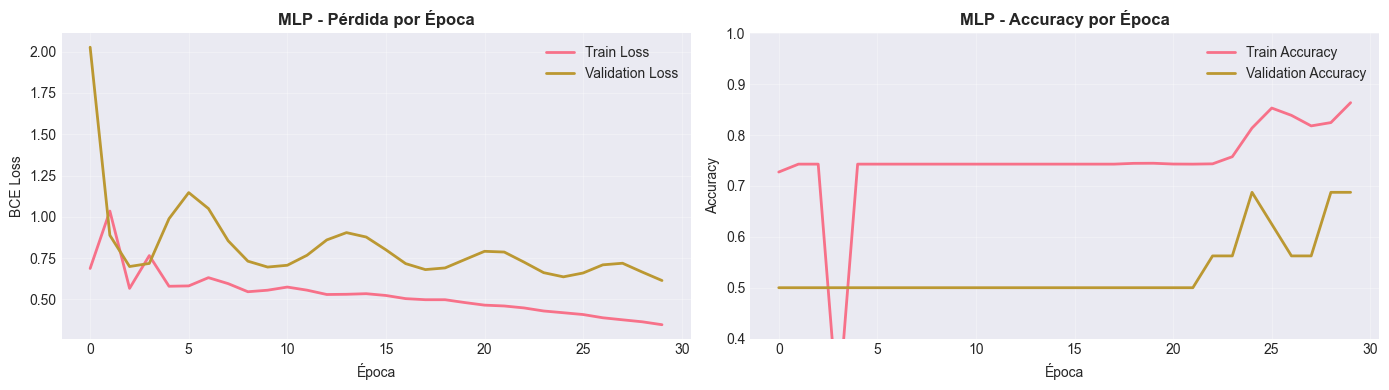

Accuracy final MLP - Train: 0.8637
Accuracy final MLP - Val:   0.6875


In [44]:
# Curvas de entrenamiento y validación (Loss y Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('MLP - Pérdida por Época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('MLP - Accuracy por Época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.4, 1.0])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Accuracy final MLP - Train: {history['train_acc'][-1]:.4f}")
print(f"Accuracy final MLP - Val:   {history['val_acc'][-1]:.4f}")

In [45]:
# Evaluación final del MLP en test y comparación con baseline (Semana 2)
mlp_model.eval()
with torch.no_grad():
    y_test_pred_proba_mlp = mlp_model(X_test_t).cpu().numpy().flatten()
y_test_pred_mlp = (y_test_pred_proba_mlp >= 0.5).astype(int)

mlp_test_accuracy = accuracy_score(y_test, y_test_pred_mlp)
mlp_test_precision = precision_score(y_test, y_test_pred_mlp)
mlp_test_recall = recall_score(y_test, y_test_pred_mlp)
mlp_test_f1 = f1_score(y_test, y_test_pred_mlp)

comparison_df = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística (Semana 2)',
        'Accuracy (Test)': test_accuracy,
        'Precision (Test)': test_precision,
        'Recall (Test)': test_recall,
        'F1-Score (Test)': test_f1,
        'Accuracy (Val final)': final_val_acc
    },
    {
        'Modelo': 'MLP 4096-512-256-1 (Semana 3)',
        'Accuracy (Test)': mlp_test_accuracy,
        'Precision (Test)': mlp_test_precision,
        'Recall (Test)': mlp_test_recall,
        'F1-Score (Test)': mlp_test_f1,
        'Accuracy (Val final)': history['val_acc'][-1]
    }
])

for col in ['Accuracy (Test)', 'Precision (Test)', 'Recall (Test)', 'F1-Score (Test)', 'Accuracy (Val final)']:
    comparison_df[col] = comparison_df[col].map(lambda x: f'{x:.4f}')

print('Comparación de modelos (Semana 2 vs Semana 3):')
display(comparison_df)

Comparación de modelos (Semana 2 vs Semana 3):


,Modelo,Accuracy (Test),Precision (Test),Recall (Test),F1-Score (Test),Accuracy (Val final)
0,Regresión Logística (Semana 2),0.7436,0.7114,0.9923,0.8287,0.6875
1,MLP 4096-512-256-1 (Semana 3),0.7500,0.7259,0.9641,0.8282,0.6875
